**Different Optimizers performance**

**Implementation of SGD**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

def calculate_accuracy(y_true, y_pred, tolerance=5.0):
    correct = np.abs(y_true - y_pred) <= tolerance
    return np.mean(correct) * 100


In [ ]:
n_layers = 10
input_size = 1
hidden_size = 1
output_size = 1

learning_rate = 0.1
epochs = 100

In [ ]:
X = np.array([[1], [2], [3], [4]], dtype=float)
y = np.array([[2], [4], [6], [8]], dtype=float)

In [ ]:
weights = []
biases = []

total_layers = n_layers + 1

for i in range(total_layers):
    if i == 0:
        w = np.random.randn(input_size, hidden_size)
        b = np.zeros((1, hidden_size))
    elif i == total_layers - 1:
        w = np.random.randn(hidden_size, output_size)
        b = np.zeros((1, output_size))
    else:
        w = np.random.randn(hidden_size, hidden_size)
        b = np.zeros((1, hidden_size))

    weights.append(w)
    biases.append(b)


In [ ]:
losses_sgd = []

for epoch in range(epochs):

    activations = [X]

    # Forward propagation
    for i in range(len(weights)):
        z = np.dot(activations[i], weights[i]) + biases[i]
        activations.append(sigmoid(z))

    output = activations[-1]

    # Loss
    loss = np.mean((y - output) ** 2)
    losses_sgd.append(loss)

    # Backpropagation
    error = (y - output) * sigmoid_derivative(output)

    for i in reversed(range(len(weights))):
        dW = np.dot(activations[i].T, error)
        dB = np.sum(error, axis=0, keepdims=True)

        #SGD update
        weights[i] += learning_rate * dW
        biases[i] += learning_rate * dB

        if i != 0:
            error = np.dot(error, weights[i].T) * sigmoid_derivative(activations[i])


In [ ]:
# Final prediction after training
pred_sgd = output

# Calculate accuracy
accuracy_sgd = calculate_accuracy(y, pred_sgd)

print("SGD Accuracy:", accuracy_sgd, "%")


SGD Accuracy: 50.0 %


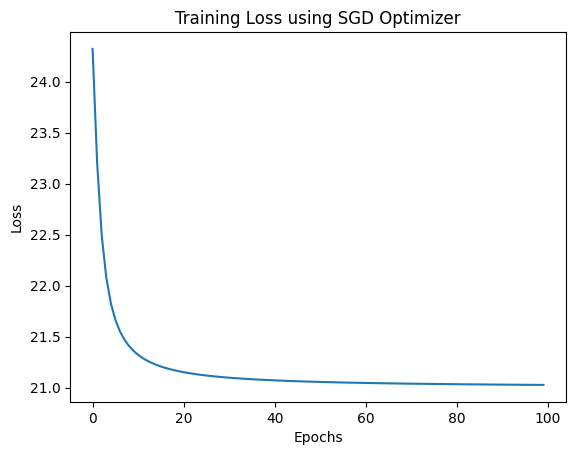

In [ ]:
plt.plot(losses_sgd)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss using SGD Optimizer")
plt.show()

**Implementing SGD With Momentum**

In [ ]:
weights = []
biases = []

for i in range(total_layers):
    if i == 0:
        w = np.random.randn(input_size, hidden_size)
        b = np.random.randn(1, hidden_size)
    elif i == total_layers - 1:
        w = np.random.randn(hidden_size, output_size)
        b = np.random.randn(1, output_size)
    else:
        w = np.random.randn(hidden_size, hidden_size)
        b = np.random.randn(1, hidden_size)

    weights.append(w)
    biases.append(b)


In [ ]:
# Momentum hyperparameter
beta = 0.9

# Initialize velocity terms
v_weights = [np.zeros_like(w) for w in weights]
v_biases = [np.zeros_like(b) for b in biases]

In [ ]:

losses_momentum = []

for epoch in range(epochs):

    activations = [X]

    # Forward propagation
    for i in range(len(weights)):
        z = np.dot(activations[i], weights[i]) + biases[i]
        activations.append(sigmoid(z))

    output = activations[-1]

    # Compute loss
    loss = np.mean((y - output) ** 2)
    losses_momentum.append(loss)

    # Backpropagation
    error = (y - output) * sigmoid_derivative(output)

    for i in reversed(range(len(weights))):
        dW = np.dot(activations[i].T, error)
        dB = np.sum(error, axis=0, keepdims=True)

        # Momentum update
        v_weights[i] = beta * v_weights[i] + learning_rate * dW
        v_biases[i] = beta * v_biases[i] + learning_rate * dB

        weights[i] += v_weights[i]
        biases[i] += v_biases[i]

        if i != 0:
            error = np.dot(error, weights[i].T) * sigmoid_derivative(activations[i])


In [ ]:
# Final prediction after SGD with Momentum
pred_momentum = output

# Calculate accuracy
accuracy_momentum = calculate_accuracy(y, pred_momentum)

print("SGD with Momentum Accuracy:", accuracy_momentum, "%")


SGD with Momentum Accuracy: 50.0 %


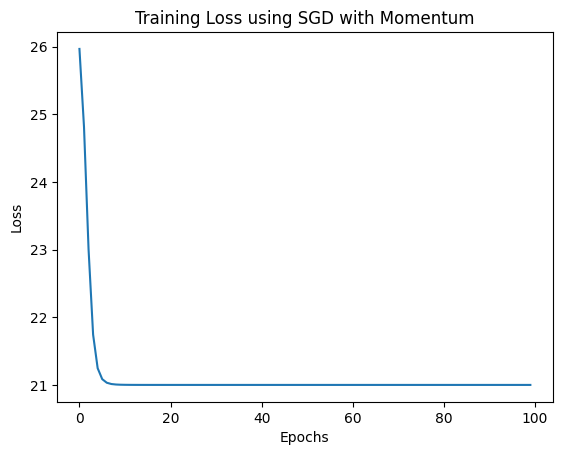

In [ ]:
plt.plot(losses_momentum)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss using SGD with Momentum")
plt.show()

**Implementation of Nesterov Accelerated Gradient (NAG)**

In [ ]:
weights = []
biases = []

for i in range(total_layers):
    if i == 0:
        w = np.random.randn(input_size, hidden_size)
        b = np.random.randn(1, hidden_size)
    elif i == total_layers - 1:
        w = np.random.randn(hidden_size, output_size)
        b = np.random.randn(1, output_size)
    else:
        w = np.random.randn(hidden_size, hidden_size)
        b = np.random.randn(1, hidden_size)

    weights.append(w)
    biases.append(b)


In [ ]:
beta = 0.9

v_weights = [np.zeros_like(w) for w in weights]
v_biases = [np.zeros_like(b) for b in biases]

losses_nag = []

In [ ]:
for epoch in range(epochs):

    # look ahead weights
    lookahead_weights = [ weights[i] + beta * v_weights[i] for i in range(len(weights))]
    lookahead_biases = [ biases[i] + beta * v_biases[i] for i in range(len(biases))]


    activations = [X]

    for i in range(len(lookahead_weights)):
        z = np.dot(activations[i], lookahead_weights[i]) + lookahead_biases[i]
        activations.append(sigmoid(z))

    output = activations[-1]

    #loss
    loss = np.mean((y - output) ** 2)
    losses_nag.append(loss)

    # BACKPROP
    error = (y - output) * sigmoid_derivative(output)

    for i in reversed(range(len(weights))):

        dW = np.dot(activations[i].T, error)
        dB = np.sum(error, axis=0, keepdims=True)

        # NAG UPDATE
        v_weights[i] = beta * v_weights[i] + learning_rate * dW
        v_biases[i]  = beta * v_biases[i]  + learning_rate * dB

        weights[i] += v_weights[i]
        biases[i]  += v_biases[i]

        if i != 0:
            error = np.dot(error, lookahead_weights[i].T) * sigmoid_derivative(activations[i])


In [ ]:
# Final prediction after NAG
pred_nag = output

# Calculate accuracy
accuracy_nag = calculate_accuracy(y, pred_nag)

print("NAG Accuracy:", accuracy_nag, "%")


NAG Accuracy: 50.0 %


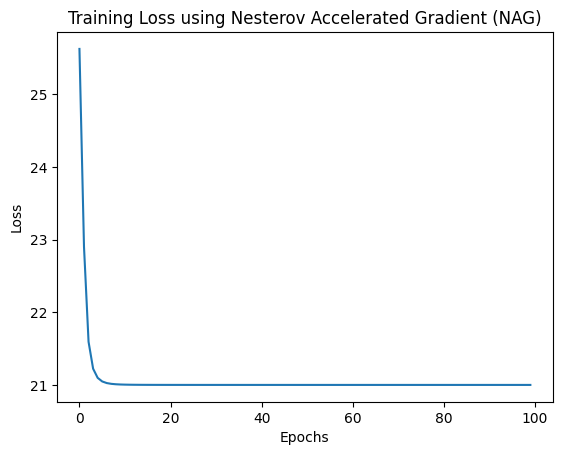

In [ ]:
plt.plot(losses_nag)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss using Nesterov Accelerated Gradient (NAG)")
plt.show()


**Implementation of AdaGrad**

In [ ]:
weights = []
biases = []

for i in range(total_layers):
    if i == 0:
        w = np.random.randn(input_size, hidden_size)
        b = np.random.randn(1, hidden_size)
    elif i == total_layers - 1:
        w = np.random.randn(hidden_size, output_size)
        b = np.random.randn(1, output_size)
    else:
        w = np.random.randn(hidden_size, hidden_size)
        b = np.random.randn(1, hidden_size)

    weights.append(w)
    biases.append(b)


In [ ]:
epsilon = 1e-8  # small value to avoid division by zero

# Accumulated squared gradients
G_weights = [np.zeros_like(w) for w in weights]
G_biases = [np.zeros_like(b) for b in biases]

losses_adagrad = []

for epoch in range(epochs):

    activations = [X]

    # Forward propagation
    for i in range(len(weights)):
        z = np.dot(activations[i], weights[i]) + biases[i]
        activations.append(sigmoid(z))

    output = activations[-1]

    # Loss
    loss = np.mean((y - output) ** 2)
    losses_adagrad.append(loss)

    # Backpropagation
    error = (y - output) * sigmoid_derivative(output)

    for i in reversed(range(len(weights))):

        dW = np.dot(activations[i].T, error)
        dB = np.sum(error, axis=0, keepdims=True)

        #AdaGrad update
        G_weights[i] += dW ** 2
        G_biases[i] += dB ** 2

        weights[i] += learning_rate * dW / (np.sqrt(G_weights[i]) + epsilon)
        biases[i] += learning_rate * dB / (np.sqrt(G_biases[i]) + epsilon)

        if i != 0:
            error = np.dot(error, weights[i].T) * sigmoid_derivative(activations[i])


In [ ]:
# Final prediction after AdaGrad
pred_adagrad = output

# Calculate accuracy
accuracy_adagrad = calculate_accuracy(y, pred_adagrad)

print("AdaGrad Accuracy:", accuracy_adagrad, "%")


AdaGrad Accuracy: 50.0 %


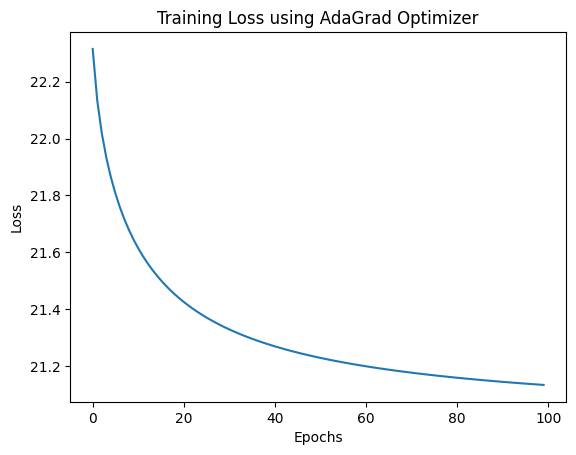

In [ ]:
plt.plot(losses_adagrad)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss using AdaGrad Optimizer")
plt.show()


**Implementation of RMSProp**

In [ ]:
weights = []
biases = []

for i in range(total_layers):
    if i == 0:
        w = np.random.randn(input_size, hidden_size)
        b = np.random.randn(1, hidden_size)
    elif i == total_layers - 1:
        w = np.random.randn(hidden_size, output_size)
        b = np.random.randn(1, output_size)
    else:
        w = np.random.randn(hidden_size, hidden_size)
        b = np.random.randn(1, hidden_size)

    weights.append(w)
    biases.append(b)


In [ ]:
beta = 0.9        # decay rate
epsilon = 1e-8   # small constant

# Moving average of squared gradients
S_weights = [np.zeros_like(w) for w in weights]
S_biases = [np.zeros_like(b) for b in biases]

losses_rmsprop = []

for epoch in range(epochs):

    activations = [X]

    # Forward propagation
    for i in range(len(weights)):
        z = np.dot(activations[i], weights[i]) + biases[i]
        activations.append(sigmoid(z))

    output = activations[-1]

    # Loss
    loss = np.mean((y - output) ** 2)
    losses_rmsprop.append(loss)

    # Backpropagation
    error = (y - output) * sigmoid_derivative(output)

    for i in reversed(range(len(weights))):

        dW = np.dot(activations[i].T, error)
        dB = np.sum(error, axis=0, keepdims=True)

        # -------- RMSprop update --------
        S_weights[i] = beta * S_weights[i] + (1 - beta) * (dW ** 2)
        S_biases[i]  = beta * S_biases[i]  + (1 - beta) * (dB ** 2)

        weights[i] += learning_rate * dW / (np.sqrt(S_weights[i]) + epsilon)
        biases[i]  += learning_rate * dB / (np.sqrt(S_biases[i]) + epsilon)

        if i != 0:
            error = np.dot(error, weights[i].T) * sigmoid_derivative(activations[i])


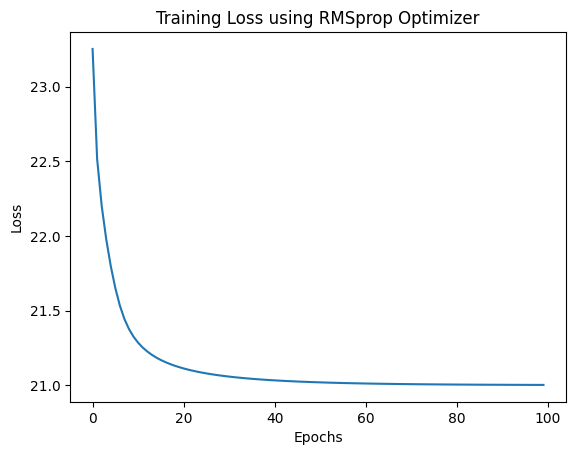

In [ ]:
plt.plot(losses_rmsprop)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss using RMSprop Optimizer")
plt.show()


**Implementation of Adam**

In [ ]:
weights = []
biases = []

for i in range(total_layers):
    if i == 0:
        w = np.random.randn(input_size, hidden_size)
        b = np.random.randn(1, hidden_size)
    elif i == total_layers - 1:
        w = np.random.randn(hidden_size, output_size)
        b = np.random.randn(1, output_size)
    else:
        w = np.random.randn(hidden_size, hidden_size)
        b = np.random.randn(1, hidden_size)

    weights.append(w)
    biases.append(b)


In [ ]:
beta1 = 0.9     # momentum term
beta2 = 0.999   # RMSprop term
epsilon = 1e-8

# First moment (mean of gradients)
m_weights = [np.zeros_like(w) for w in weights]
m_biases  = [np.zeros_like(b) for b in biases]

# Second moment (mean of squared gradients)
v_weights = [np.zeros_like(w) for w in weights]
v_biases  = [np.zeros_like(b) for b in biases]

losses_adam = []

for epoch in range(1, epochs + 1):

    activations = [X]

    # Forward propagation
    for i in range(len(weights)):
        z = np.dot(activations[i], weights[i]) + biases[i]
        activations.append(sigmoid(z))

    output = activations[-1]

    # Loss
    loss = np.mean((y - output) ** 2)
    losses_adam.append(loss)

    # Backpropagation
    error = (y - output) * sigmoid_derivative(output)

    for i in reversed(range(len(weights))):

        dW = np.dot(activations[i].T, error)
        dB = np.sum(error, axis=0, keepdims=True)

        # -------- Adam update --------
        m_weights[i] = beta1 * m_weights[i] + (1 - beta1) * dW
        m_biases[i]  = beta1 * m_biases[i]  + (1 - beta1) * dB

        v_weights[i] = beta2 * v_weights[i] + (1 - beta2) * (dW ** 2)
        v_biases[i]  = beta2 * v_biases[i]  + (1 - beta2) * (dB ** 2)

        # Bias correction
        m_hat_w = m_weights[i] / (1 - beta1 ** epoch)
        m_hat_b = m_biases[i]  / (1 - beta1 ** epoch)

        v_hat_w = v_weights[i] / (1 - beta2 ** epoch)
        v_hat_b = v_biases[i]  / (1 - beta2 ** epoch)

        # Update parameters
        weights[i] += learning_rate * m_hat_w / (np.sqrt(v_hat_w) + epsilon)
        biases[i]  += learning_rate * m_hat_b / (np.sqrt(v_hat_b) + epsilon)

        if i != 0:
            error = np.dot(error, weights[i].T) * sigmoid_derivative(activations[i])


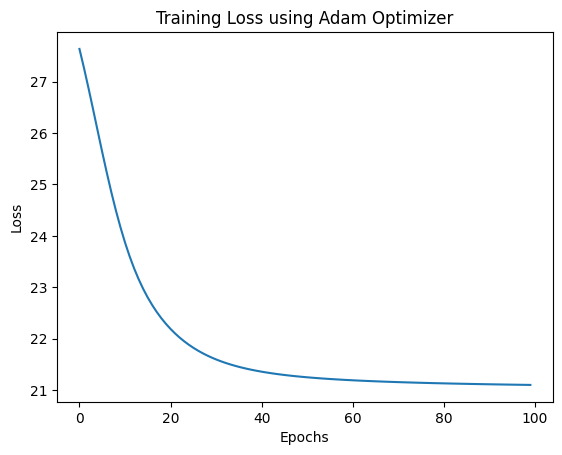

In [ ]:
plt.plot(losses_adam)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss using Adam Optimizer")
plt.show()


**Implemantation of the Adamw**

In [ ]:
weights = []
biases = []

for i in range(total_layers):
    if i == 0:
        w = np.random.randn(input_size, hidden_size)
        b = np.random.randn(1, hidden_size)
    elif i == total_layers - 1:
        w = np.random.randn(hidden_size, output_size)
        b = np.random.randn(1, output_size)
    else:
        w = np.random.randn(hidden_size, hidden_size)
        b = np.random.randn(1, hidden_size)

    weights.append(w)
    biases.append(b)


In [ ]:
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8
weight_decay = 0.01  # regularization term

m_weights = [np.zeros_like(w) for w in weights]
m_biases  = [np.zeros_like(b) for b in biases]

v_weights = [np.zeros_like(w) for w in weights]
v_biases  = [np.zeros_like(b) for b in biases]

losses_adamw = []

for epoch in range(1, epochs + 1):

    activations = [X]

    # Forward propagation
    for i in range(len(weights)):
        z = np.dot(activations[i], weights[i]) + biases[i]
        activations.append(sigmoid(z))

    output = activations[-1]

    # Loss
    loss = np.mean((y - output) ** 2)
    losses_adamw.append(loss)

    # Backpropagation
    error = (y - output) * sigmoid_derivative(output)

    for i in reversed(range(len(weights))):

        dW = np.dot(activations[i].T, error)
        dB = np.sum(error, axis=0, keepdims=True)

        # AdamW update
        m_weights[i] = beta1 * m_weights[i] + (1 - beta1) * dW
        m_biases[i]  = beta1 * m_biases[i]  + (1 - beta1) * dB

        v_weights[i] = beta2 * v_weights[i] + (1 - beta2) * (dW ** 2)
        v_biases[i]  = beta2 * v_biases[i]  + (1 - beta2) * (dB ** 2)

        # Bias correction
        m_hat_w = m_weights[i] / (1 - beta1 ** epoch)
        m_hat_b = m_biases[i]  / (1 - beta1 ** epoch)

        v_hat_w = v_weights[i] / (1 - beta2 ** epoch)
        v_hat_b = v_biases[i]  / (1 - beta2 ** epoch)

        # Weight decay (decoupled)
        weights[i] *= (1 - learning_rate * weight_decay)

        # Parameter update
        weights[i] += learning_rate * m_hat_w / (np.sqrt(v_hat_w) + epsilon)
        biases[i]  += learning_rate * m_hat_b / (np.sqrt(v_hat_b) + epsilon)

        if i != 0:
            error = np.dot(error, weights[i].T) * sigmoid_derivative(activations[i])


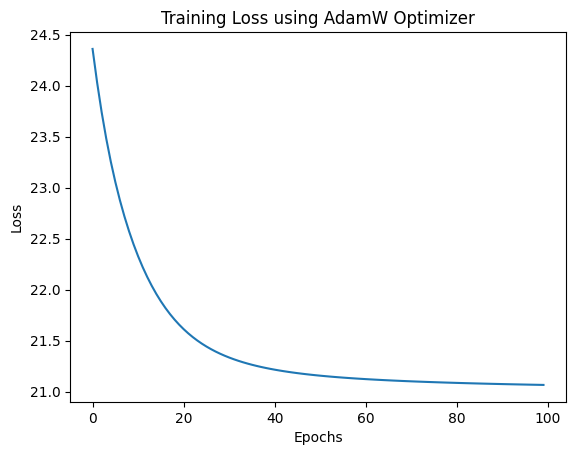

In [ ]:
plt.plot(losses_adamw)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss using AdamW Optimizer")
plt.show()

**Comparison of all optimizers**

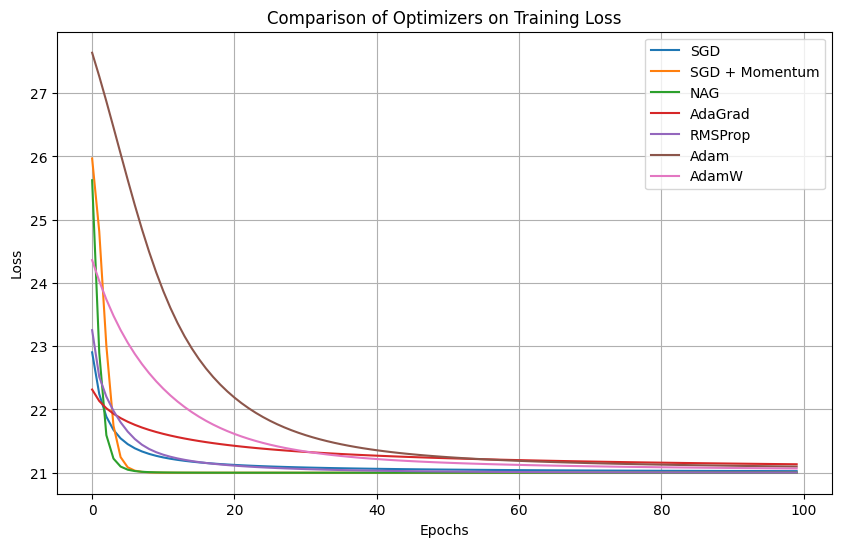

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(losses_sgd, label="SGD")
plt.plot(losses_momentum, label="SGD + Momentum")
plt.plot(losses_nag, label="NAG")
plt.plot(losses_adagrad, label="AdaGrad")
plt.plot(losses_rmsprop, label="RMSProp")
plt.plot(losses_adam, label="Adam")
plt.plot(losses_adamw, label="AdamW")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Comparison of Optimizers on Training Loss")
plt.legend()
plt.grid(True)
plt.show()
